<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Supervised/basics/MissingValues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sklearn

In [4]:
data = {
    'size': ['XL', 'L', np.nan, 'L', 'M'],
    'color': ['red', 'green', 'blue', 'green', 'red'],
    'gender': ['female', 'male', np.nan, 'female', 'female'],
    'price': [199.0, 89.0, np.nan, 129.0, 79.0],
    'weight': [500, 450, 300, np.nan, np.nan],
    'bought': ['yes', 'no', 'yes', 'no', 'yes']
}

In [5]:
df_raw = pd.DataFrame(data=data)
df_raw

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,NaN,yes


In [6]:
df = df_raw.copy()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    4 non-null      object 
 1   color   5 non-null      object 
 2   gender  4 non-null      object 
 3   price   4 non-null      float64
 4   weight  3 non-null      float64
 5   bought  5 non-null      object 
dtypes: float64(2), object(4)
memory usage: 372.0+ bytes


In [10]:
df.isnull()

,size,color,gender,price,weight,bought
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,True,False,True,True,False,False
3,False,False,False,False,True,False
4,False,False,False,False,True,False


In [11]:
df.isnull().sum()

,0
size,1
color,0
gender,1
price,1
weight,2
bought,0


In [12]:
df.isnull().sum().sum()

np.int64(5)

In [13]:
df.isnull().sum() / len(df)

,0
size,0.2
color,0.0
gender,0.2
price,0.2
weight,0.4
bought,0.0


In [14]:
from sklearn.impute import SimpleImputer

In [15]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,NaN,yes


In [16]:
imputer.fit(df[['weight']])

SimpleImputer()

In [17]:
from sklearn import set_config
set_config(display='text')
imputer.fit(df[['weight']])

SimpleImputer()

In [18]:
imputer.statistics_

array([416.66666667])

In [19]:
imputer.transform(df[['weight']])

array([[500.        ],
       [450.        ],
       [300.        ],
       [416.66666667],
       [416.66666667]])

In [20]:
df['weight'] = imputer.transform(df[['weight']])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.000000,yes
1,L,green,male,89.0,450.000000,no
2,NaN,blue,NaN,NaN,300.000000,yes
3,L,green,female,129.0,416.666667,no
4,M,red,female,79.0,416.666667,yes


In [21]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=99.0)
imputer.fit_transform(df[['price']])

array([[199.],
       [ 89.],
       [ 99.],
       [129.],
       [ 79.]])

In [22]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='L')
imputer.fit_transform(df[['size']])

array([['XL'],
       ['L'],
       ['L'],
       ['L'],
       ['M']], dtype=object)

In [23]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.000000,yes
1,L,green,male,89.0,450.000000,no
2,NaN,blue,NaN,NaN,300.000000,yes
3,L,green,female,129.0,416.666667,no
4,M,red,female,79.0,416.666667,yes


In [24]:
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer.fit_transform(df[['size']])

array([['XL'],
       ['L'],
       ['L'],
       ['L'],
       ['M']], dtype=object)

In [25]:
df = df_raw.copy()

In [26]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,NaN,yes


In [27]:
df.isnull().sum()

,0
size,1
color,0
gender,1
price,1
weight,2
bought,0


In [28]:
pd.isnull(df['weight'])

,weight
0,False
1,False
2,False
3,True
4,True


In [30]:
df[pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,NaN,yes


In [31]:
df[~pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes


In [32]:
pd.notnull(df['weight'])

,weight
0,True
1,True
2,True
3,False
4,False


In [33]:
df[pd.notnull(df['weight'])]

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes


In [34]:
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,NaN,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,NaN,yes


In [35]:
df.fillna(value='brak')

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,brak,blue,brak,brak,300.0,yes
3,L,green,female,129.0,brak,no
4,M,red,female,79.0,brak,yes


In [36]:
df.fillna(value=0.0)

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,0.0,blue,0.0,0.0,300.0,yes
3,L,green,female,129.0,0.0,no
4,M,red,female,79.0,0.0,yes


In [37]:
df['size'].fillna(value='L', inplace=True)

/tmp/ipykernel_510/2916502479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna(value='L', inplace=True)


In [40]:
df.dropna()

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no


In [41]:
df = df.dropna()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no


In [42]:
import pandas as pd
import numpy as np

data = {'price': [108, 109, 110, 110, 109, np.nan, np.nan, 112, 111, 111]}
date_range = pd.date_range(start='01-01-2020 09:00', end='01-01-2020 18:00', periods=10)

df = pd.DataFrame(data=data, index=date_range)
df

,price
2020-01-01 09:00:00,108.0
2020-01-01 10:00:00,109.0
2020-01-01 11:00:00,110.0
2020-01-01 12:00:00,110.0
2020-01-01 13:00:00,109.0
2020-01-01 14:00:00,NaN
2020-01-01 15:00:00,NaN
2020-01-01 16:00:00,112.0
2020-01-01 17:00:00,111.0
2020-01-01 18:00:00,111.0


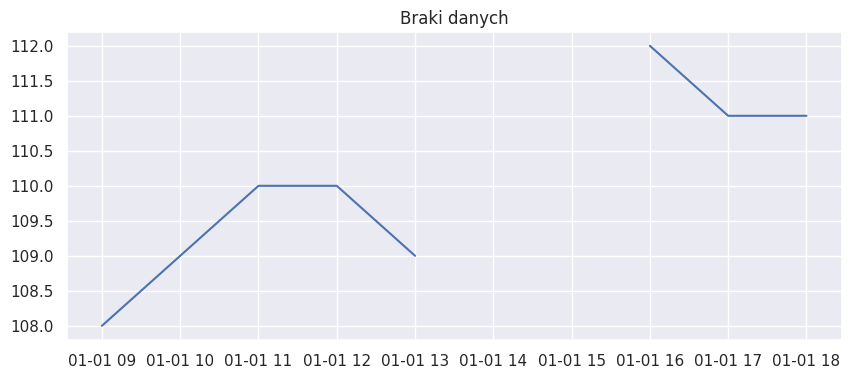

In [43]:
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
import seaborn as sns

register_matplotlib_converters()
sns.set()

plt.figure(figsize=(10, 4))
plt.title('Braki danych')
_ = plt.plot(df.price)

In [44]:
import plotly.express as px
df_plotly = df.reset_index()
px.line(df_plotly,'index','price',width=600,height=400, title='Szeregi Czasowe - braki danych')

In [45]:
df_plotly = df_plotly.dropna()
px.line(df_plotly, 'index', 'price', width=600, height=400,
        title='Szeregi czasowe - braki danych')

In [46]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(0)
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - wstawienie 0')

In [47]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(df_plotly['price'].mean())
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - wstawienie średniej')

In [48]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].interpolate()
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - interpolacja')

In [49]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(method='ffill')
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych - forward fill')

/tmp/ipykernel_510/1158695887.py:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [50]:
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(method='bfill')
px.line(df_plotly, 'index', 'price_fill', width=600, height=400,
        title='Szeregi czasowe - braki danych')

/tmp/ipykernel_510/4114141591.py:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

